## Упражнение 03. Столбчатая диаграмма

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

from pandas import DataFrame
from sqlite3 import Connection

### 1. Создаем соединение с базой данных с помощью библиотеки sqlite3

In [2]:
conn=sqlite3.connect('../data/checking-logs.sqlite')

### 2. Делаем всё необходимое, чтобы получить график как на примере:
#### - Анализируй только пользователей (не учитывай админов);
#### - Размер шрифта и размер фигуры — те же, что раньше;
#### - Подготовь два списка значений для входа гистограммы: отдельно для рабочих дней и для выходных;
#### - Размер фигуры — тот же; размер шрифта и цветовую палитру выбирай сам;
#### - Прозрачность «передней» гистограммы: alpha = 0.7.


In [3]:
query = """
SELECT checker.timestamp as datetime FROM checker 
WHERE checker.uid LIKE 'user_%';
"""
df: DataFrame = pd.io.sql.read_sql(query,conn,parse_dates=["datetime", ] )
df['hour'] = df['datetime'].dt.hour
df["day_type"] = df["datetime"].dt.dayofweek.apply(lambda day: "weekend" if day >= 5 else "working_day", )
df

,datetime,hour,day_type
0,2020-04-17 05:19:02.744528,5,working_day
1,2020-04-17 05:22:35.249331,5,working_day
2,2020-04-17 05:22:45.549397,5,working_day
3,2020-04-17 05:34:14.691200,5,working_day
4,2020-04-17 05:34:24.422370,5,working_day
...,...,...,...
3202,2020-05-21 20:19:06.872761,20,working_day
3203,2020-05-21 20:22:41.785725,20,working_day
3204,2020-05-21 20:22:41.877806,20,working_day
3205,2020-05-21 20:37:00.129678,20,working_day


In [7]:
weekends: list = list(df[df["day_type"] == "weekend"]["hour"], )
working_days: list = list(df[df["day_type"] == "working_day"]["hour"], )
working_days[: 20]

[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 11, 11, 11, 11, 11, 11, 11]

In [8]:
weekends[: 20]

[7, 13, 13, 13, 13, 13, 14, 14, 14, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15]

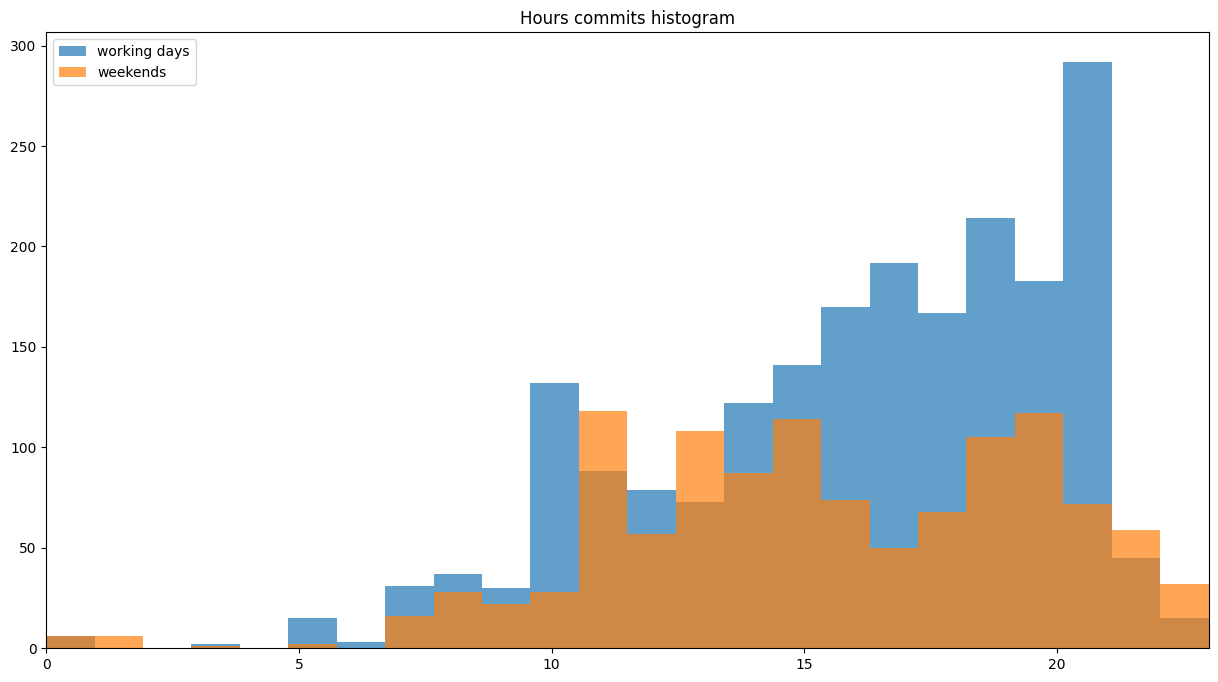

In [9]:
plt.figure(figsize=(15, 8, ), )
plt.hist(
    working_days,
    bins=24,
    alpha=0.7,
)
plt.hist(
    weekends,
    bins=24,
    alpha=0.7,
)
plt.xlim(0, 23, )
plt.title("Hours commits histogram", )
plt.legend(["working days", "weekends", ], loc="upper left", );

### Есть ли часы, когда общее число коммитов было выше в выходные, чем в рабочие дни?

In [10]:
df["date"] = df["datetime"].dt.date
df

,datetime,hour,day_type,date
0,2020-04-17 05:19:02.744528,5,working_day,2020-04-17
1,2020-04-17 05:22:35.249331,5,working_day,2020-04-17
2,2020-04-17 05:22:45.549397,5,working_day,2020-04-17
3,2020-04-17 05:34:14.691200,5,working_day,2020-04-17
4,2020-04-17 05:34:24.422370,5,working_day,2020-04-17
...,...,...,...,...
3202,2020-05-21 20:19:06.872761,20,working_day,2020-05-21
3203,2020-05-21 20:22:41.785725,20,working_day,2020-05-21
3204,2020-05-21 20:22:41.877806,20,working_day,2020-05-21
3205,2020-05-21 20:37:00.129678,20,working_day,2020-05-21


In [11]:
df.drop(columns=["datetime", ], inplace=True, )
df

,hour,day_type,date
0,5,working_day,2020-04-17
1,5,working_day,2020-04-17
2,5,working_day,2020-04-17
3,5,working_day,2020-04-17
4,5,working_day,2020-04-17
...,...,...,...
3202,20,working_day,2020-05-21
3203,20,working_day,2020-05-21
3204,20,working_day,2020-05-21
3205,20,working_day,2020-05-21


In [12]:
df = df.groupby(by=["hour", "day_type", ], ).size().reset_index(name="commits", )
df

,hour,day_type,commits
0,0,weekend,6
1,0,working_day,6
2,1,weekend,6
3,3,weekend,1
4,3,working_day,2
5,5,weekend,2
6,5,working_day,15
7,6,working_day,3
8,7,weekend,16
9,7,working_day,31


In [13]:
weekends: DataFrame = df[df["day_type"] == "weekend"]
working_days: DataFrame = df[df["day_type"] == "working_day"]
weekends.head()

,hour,day_type,commits
0,0,weekend,6
2,1,weekend,6
3,3,weekend,1
5,5,weekend,2
8,7,weekend,16


In [14]:
working_days.head()

,hour,day_type,commits
1,0,working_day,6
4,3,working_day,2
6,5,working_day,15
7,6,working_day,3
9,7,working_day,31


In [15]:
weekends = pd.merge(DataFrame({"hour": range(24, ), }, ), weekends,on="hour",how="left",).drop(columns=["day_type", ], )
working_days = pd.merge(DataFrame({"hour": range(24, ), }, ), working_days, on="hour", how="left",).drop(columns=["day_type", ], )
weekends.fillna(0, inplace=True, )
working_days.fillna(0, inplace=True, )
weekends.head()

,hour,commits
0,0,6.0
1,1,6.0
2,2,0.0
3,3,1.0
4,4,0.0


In [16]:
working_days.head()

,hour,commits
0,0,6.0
1,1,0.0
2,2,0.0
3,3,2.0
4,4,0.0


In [18]:
df = pd.merge(
    weekends,
    working_days,
    on="hour",
    how="inner",
).rename(columns={"commits_x": "weekends", "commits_y": "working_days", }, )
df

,hour,weekends,working_days
0,0,6.0,6.0
1,1,6.0,0.0
2,2,0.0,0.0
3,3,1.0,2.0
4,4,0.0,0.0
5,5,2.0,15.0
6,6,0.0,3.0
7,7,16.0,31.0
8,8,28.0,37.0
9,9,22.0,30.0


In [19]:
df["diff"] = df["weekends"] - df["working_days"]

In [20]:
print(f"{df.sort_values(by=["diff", ], ascending=False, )["hour"].values[: 4]}.", )

[13 11 23 22].


### Закрываем соединение с базой данных.

In [10]:
conn.close()